In [56]:
import re
import numpy as np
from pathlib import Path

FLOAT = False
expon = 23 if FLOAT else 52  # 52 for normals vs 53 for exp

# Path to the header file
path = Path("ziggurat_const_float.h" if FLOAT else "ziggurat_constants.h")
text = path.read_text()

# --- helpers -------------------------------------------------------------
def parse_uint32_array(name, text):
    m = re.search(
        rf"static const uint32_t {name}\[\] = \{{(.*?)\}};",
        text,
        re.S,
    )
    if not m:
        raise ValueError(f"Array {name} not found")
    body = m.group(1)
    vals = re.findall(r"0x[0-9A-Fa-f]+", body)
    return np.array([int(v.rstrip("UL"), 16) for v in vals], dtype=np.uint32)


def parse_float_array(name, text):
    m = re.search(
        rf"static const float {name}\[\] = \{{(.*?)\}};",
        text,
        re.S,
    )
    if not m:
        raise ValueError(f"Array {name} not found")
    body = m.group(1)
    vals = re.findall(r"[-+]?\d*\.\d+(?:[eE][-+]?\d+)?f?", body)
    return np.array([v.rstrip("f") for v in vals], dtype=np.float32)


def parse_float_scalar(name, text):
    m = re.search(
        rf"static const float {name}\s*=\s*([-+]?\d*\.\d+(?:[eE][-+]?\d+)?f?);",
        text,
    )
    if not m:
        raise ValueError(f"Scalar {name} not found")
    return float(m.group(1).rstrip("f"))

def parse_uint64_array(name, text):
    m = re.search(
        rf"static const uint64_t {name}\[\] = \{{(.*?)\}};",
        text,
        re.S,
    )
    print('m=', m)
    if not m:
        raise ValueError(f"Array {name} not found")
    body = m.group(1)
    vals = re.findall(r"0x[0-9A-Fa-f]+(?:[uUlL]+)?", body)
    return np.array([int(re.sub(r"[uUlL]+$", "", v), 16) for v in vals], dtype=np.uint64)

def parse_double_array(name, text):
    m = re.search(
        rf"static const double {name}\[\] = \{{(.*?)\}};",
        text,
        re.S,
    )
    if not m:
        raise ValueError(f"Array {name} not found")
    body = m.group(1)
    vals = re.findall(r"[-+]?\d*\.\d+(?:[eE][-+]?\d+)?", body)
    return np.array(vals, dtype=np.float64)


def parse_double_scalar(name, text):
    m = re.search(
        rf"static const double {name}\s*=\s*([-+]?\d*\.\d+(?:[eE][-+]?\d+)?);",
        text,
    )
    if not m:
        raise ValueError(f"Scalar {name} not found")
    return float(m.group(1))


# --- parse everything ----------------------------------------------------
if FLOAT:
    ki = parse_uint32_array("ki_float", text)
    wi = parse_float_array("wi_float", text)
    fi = parse_float_array("fi_float", text)
    r = parse_float_scalar("ziggurat_nor_r_f", text)
    inv_r = parse_float_scalar("ziggurat_nor_inv_r_f", text)
else:
    ki = parse_uint64_array("ki_double", text)
    wi = parse_double_array("wi_double", text)
    fi = parse_double_array("fi_double", text)
    r = parse_double_scalar("ziggurat_nor_r", text)
    inv_r = parse_double_scalar("ziggurat_nor_inv_r", text)


# --- sanity prints -------------------------------------------------------

print("ki:", ki.shape, ki.dtype)
print("wi:", wi.shape, wi.dtype)
print("fi:", fi.shape, fi.dtype)
print("r =", r)
print("inv_r =", inv_r)
print("r * inv_r =", r * inv_r)

m= <re.Match object; span=(0, 6270), match='static const uint64_t ki_double[] = {\n    0x000E>
ki: (256,) uint64
wi: (256,) float64
fi: (256,) float64
r = 3.654152885361009
inv_r = 0.2736612373297583
r * inv_r = 1.0


In [57]:
# reconstruct x_i = wi * 2^expon, check r
xi = wi * 2**expon
xi[255], abs(r - xi[255])

(np.float64(3.654152885361009), np.float64(0.0))

In [51]:
import numpy as np

np.set_printoptions(precision=17, suppress=False)

def print_table(ki, wi, fi, n=3):
    idx1 = list(range(n));
    idx2 = list(range(len(ki)-n, len(ki)));
    print(f"{'i':>4} {'ki':>20} {'wi':>22} {'fi':>22}")
    print("-"*74)
    for i in idx1:
        print(f"{i:4d} {ki[i]:20d} {wi[i]:22.17e} {fi[i]:22.17e}")
    print("  ...")
    for i in idx2:
        print(f"{i:4d} {ki[i]:20d} {wi[i]:22.17e} {fi[i]:22.17e}")

print_table(ki, wi, fi)

   i                   ki                     wi                     fi
--------------------------------------------------------------------------
   0     4208095142473578 8.68362706080130617e-16 1.00000000000000000e+00
   1                    0 4.77933017572773682e-17 9.77101701267671596e-01
   2     3387314423973544 6.35435241740526230e-17 9.59879091800106665e-01
  ...
 253     4373832704204284 7.37242430179879891e-16 4.03797259336302356e-03
 254     4335125104963628 7.65893637080557275e-16 2.60907274610215926e-03
 255     4251099761679434 8.11384933765648419e-16 1.26028593049859797e-03


np.float64(1.1102230246251565e-16)

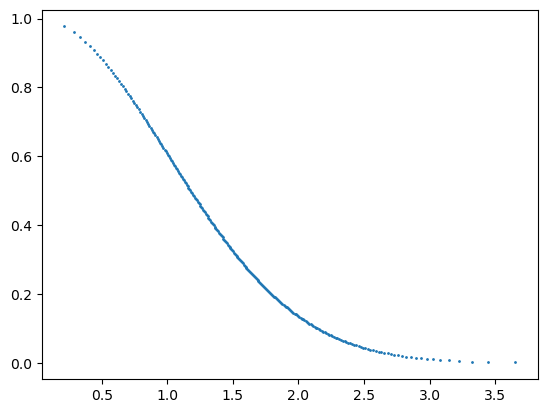

In [5]:
# Plot, and check fi
import matplotlib.pyplot as plt
plt.scatter(xi[1:], fi[1:], s=1)
yi = np.exp(-xi**2/2)
max(abs(fi[1:] - yi[1:]))

In [6]:
# Check ki:
kscaled = np.zeros(256)
kref = np.zeros(256)
kscaled[0] = ki[0]/2**expon
kscaled[1] = 0
kscaled[2:] = ki[2:]/2**expon
kref[0] = xi[255]/xi[0]
kref[1] = 0
kref[2:] = xi[1:-1]/xi[2:]
max(abs(kref - kscaled))

np.float64(1.1102230246251565e-16)

In [7]:
# check areas
from scipy.stats import norm
V = np.zeros(256)
V[1:] = (fi[:-1] - fi[1:])*xi[1:]
V[0] = fi[255]*r + np.sqrt(2*np.pi)*norm.sf(r)
V[0]
max(V) - min(V)

np.float64(2.96637714392034e-16)

In [53]:
xi[255]

np.float64(3.654152885361009)

In [58]:
dk = (1 << expon) - ki
slope_norm = np.zeros(256);
slope_norm[1:] = fi[1:]*wi[1:]*xi[1:]/(fi[:-1] - fi[1:]);
slope_norm

array([0.0000000000000000e+00, 4.3896550726226940e-16,
       1.0134911193626061e-15, 1.6115102157997953e-15,
       2.2165084635876208e-15, 2.8230368925774006e-15,
       3.4287224974015373e-15, 4.0323637424325347e-15,
       4.6332929451917203e-15, 5.2311159579923202e-15,
       5.8255908154509878e-15, 6.4165654973161501e-15,
       7.0039436244509703e-15, 7.5876644575081429e-15,
       8.1676906988928154e-15, 8.7440007766542058e-15,
       9.3165838142669058e-15, 9.8854362682937055e-15,
       1.0450559633507355e-14, 1.1011958849086667e-14,
       1.1569641175637288e-14, 1.2123615394587600e-14,
       1.2673891232057552e-14, 1.3220478941347632e-14,
       1.3763388998952625e-14, 1.4302631882736715e-14,
       1.4838217910144791e-14, 1.5370157120635366e-14,
       1.5898459190922616e-14, 1.6423133374683833e-14,
       1.6944188460593108e-14, 1.7461632744120727e-14,
       1.7975474009687607e-14, 1.8485719520604601e-14,
       1.8992376014856136e-14, 1.9495449705248258e-14,
       1.9